# DenseNet-121 (Configuration 1) 

This configuration establishes the baseline training strategy for adapting the pre-trained DenseNet-121 architecture to our specific 5-class medical imaging task.

**1. Model Architecture & Output**
*   **Classifier Head**: The top of the pre-trained DenseNet is replaced with a custom network: `Global Average Pooling (GAP) -> Batch Normalization -> Dense(256) -> Dropout(0.5) -> Dense(5)`. 
    *   *GAP* flattens the spatial features efficiently. 
    *   *Batch Normalization* stabilizes learning. 
    *   The *Dense(256)* layer learns complex combinations of features, while *Dropout(0.5)* heavily penalizes overfitting by randomly disabling 50% of the neurons during training.
*   **Output Formulation & Thresholding**: The final layer uses **Softmax** to output probabilities across **5 mutually exclusive classes** (e.g., KL grades 0-4). The final prediction simply takes the class with the highest probability (**argmax**), without any custom probability thresholds.

**2. Data Pipeline**
*   **Preprocessing & Augmentation**: The pipeline is kept extremely basic. Images are simply resized to **224x224** (the standard input size for DenseNet). No contrast enhancement (like CLAHE) or data augmentation (rotations, flips, etc.) is applied, establishing a strict baseline to see how the model performs on raw data.
*   **Class Weights**: Set to **None**, meaning the model treats all classes equally and does not artificially inflate the importance of underrepresented classes.

**3. Two-Phase Training Strategy**
The model is trained using **Categorical Cross-Entropy** (standard for multi-class tasks) in two distinct phases:
*   **Phase 1 (Warm-up)**: The base DenseNet layers are frozen. Only the new custom classifier head is trained for **10 epochs**. It uses the **Adam optimizer** with a relatively high learning rate of **1e-3 (0.001)** for rapid initial convergence.
*   **Phase 2 (Fine-tuning)**: The **last 60 layers** of the DenseNet-121 base are unfrozen, allowing the network to adapt its deeper feature extractors specifically to our X-ray dataset. The learning rate is drastically dropped to **1e-5 (0.00001)** to ensure we make only tiny, careful adjustments and don't destroy the valuable pre-trained weights.

### Model Configuration

| Parameter | Configuration 1 |
| :--- | :--- |
| **Output Formulation** | Softmax (5-class) |
| **Loss Function** | Categorical Cross-Entropy |
| **Preprocessing** | Simple resize 224×224 (no CLAHE) |
| **Data Augmentation** | None |
| **Phase 1 Optimizer** | Adam (LR=1e-3) |
| **Phase 2 Optimizer** | Adam (fixed LR=1e-5) |
| **Unfrozen Layers (P2)** | Last 60 |
| **Class Weights** | None |
| **Phase 1 Max Epochs** | 10 |
| **Classifier Head** | GAP → BN → Dense(256) → DO(0.5) → Dense(5) |
| **Threshold Optimization** | N/A (softmax argmax) |


## 1.0 Library Import

In [11]:
import json
import os
import random
import timeit
from pathlib import Path

import cv2
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import tensorflow as tf
from IPython.display import display
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    classification_report,
    cohen_kappa_score,
    confusion_matrix,
    mean_absolute_error,
    roc_auc_score,
)
from tensorflow.keras import layers, models, regularizers
from tensorflow.keras.applications.densenet import DenseNet121, preprocess_input as densenet_preprocess_input
from tensorflow.keras.callbacks import CSVLogger, EarlyStopping, ModelCheckpoint
from tensorflow.keras.preprocessing.image import ImageDataGenerator

SEED = 12049
tf.keras.utils.set_random_seed(SEED)
np.random.seed(SEED)
random.seed(SEED)

gpus = tf.config.list_physical_devices('GPU')
if gpus:
    for gpu in gpus:
        try:
            tf.config.experimental.set_memory_growth(gpu, True)
        except Exception as exc:
            print(f'Could not enable memory growth for {gpu}: {exc}')

print('TF version:', tf.__version__)
print('GPUs:', gpus)

CLASS_NAMES = ['Healthy', 'Doubtful', 'Minimal', 'Moderate', 'Severe']
NUM_CLASSES = len(CLASS_NAMES)
IMG_SIZE = 224
BATCH_SIZE = 16
MAX_EPOCHS = 50
WARMUP_EPOCHS = 10
FINE_TUNE_LAYERS = 60
EARLY_STOP_PATIENCE = 7
WARMUP_LR = 1e-3
FINE_TUNE_LR = 1e-5
IMAGE_EXTENSIONS = {'.png', '.jpg', '.jpeg', '.bmp', '.tif', '.tiff'}
MODEL_NAME = 'DenseNet121_C1'
print('MODEL_NAME:', MODEL_NAME)

Could not enable memory growth for PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'): Physical devices cannot be modified after being initialized
TF version: 2.21.0
GPUs: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
MODEL_NAME: DenseNet121_C1


In [12]:
_DENSENET121_LAST_CONV = 'conv5_block16_concat'

def get_gradcam_feature_layer(backbone):
    """Return the last 4D conv layer from a DenseNet backbone sub-model."""
    try:
        layer = backbone.get_layer(_DENSENET121_LAST_CONV)
        if len(layer.output.shape) == 4:
            return layer
    except ValueError:
        pass
    for layer in reversed(backbone.layers):
        try:
            if len(layer.output.shape) == 4:
                return layer
        except Exception:
            continue
    raise ValueError(f'Could not find a 4D conv layer in backbone: {backbone.name}')


def build_gradcam_model(trained_model):
    """Split into feature_model + head_model to avoid graph disconnection.

    The backbone sub-model has its own input tensor (input_1).
    Building a Model(inputs=trained_model.inputs, outputs=backbone_layer.output)
    always fails because those two inputs are in different graphs.
    The solution: build each piece from its own natural input.
    """
    # Step 1: isolate the DenseNet backbone
    backbone = None
    for layer in trained_model.layers:
        if isinstance(layer, tf.keras.Model) and 'densenet' in layer.name.lower():
            backbone = layer
            break

    if backbone is None:
        raise ValueError(
            'Could not find a DenseNet sub-model inside best_model. '
            f'Layer names: {[l.name for l in trained_model.layers]}'
        )

    # Step 2: find last conv layer inside the backbone
    last_conv = get_gradcam_feature_layer(backbone)
    print(f'Grad-CAM target layer: {last_conv.name}  shape: {last_conv.output.shape}')

    # Step 3: feature_model — backbone's own input → last conv output
    feature_model = tf.keras.Model(
        inputs=backbone.input,          # backbone's own input_1
        outputs=last_conv.output,
        name='gradcam_feature_model',
    )

    # Step 4: head_model — last conv output → final predictions
    # Re-use all layers after the backbone inside trained_model
    feat_shape = last_conv.output.shape[1:]  # (H, W, C) without batch
    head_input = tf.keras.Input(shape=feat_shape, name='gradcam_head_input')
    x = head_input
    # Walk trained_model layers that come after the backbone
    past_backbone = False
    for layer in trained_model.layers:
        if layer is backbone:
            past_backbone = True
            continue
        if not past_backbone:
            continue
        x = layer(x)

    head_model = tf.keras.Model(
        inputs=head_input,
        outputs=x,
        name='gradcam_head_model',
    )

    return feature_model, head_model, last_conv.name


def make_gradcam_heatmap(feature_model, head_model, img_array, pred_index=None):
    """Compute Grad-CAM heatmap using split feature/head models."""
    img_tensor = tf.cast(img_array, tf.float32)

    with tf.GradientTape() as tape:
        features = feature_model(img_tensor, training=False)
        tape.watch(features)
        preds = head_model(features, training=False)
        if pred_index is None:
            pred_index = int(tf.argmax(preds[0]))
        class_channel = preds[:, pred_index]

    grads = tape.gradient(class_channel, features)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

    heatmap = features[0] @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)
    heatmap = tf.maximum(heatmap, 0)
    max_val = tf.math.reduce_max(heatmap)
    if max_val > 0:
        heatmap = heatmap / max_val
    return heatmap.numpy()



## 1. Dataset Setup

The baseline uses the imbalanced `train` split directly. No class weighting is applied, which makes the resulting performance a true reference point for the experiment series.

In [13]:
import os
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score, balanced_accuracy_score, classification_report, mean_absolute_error, roc_auc_score, cohen_kappa_score, confusion_matrix

def get_classes(data_path, classes, data_split):
    print(f"----{data_split}----")
    knee_severity = {}
    count = 0
    for i in range(len(classes)):
        class_dir = os.path.join(data_path, str(i))
        if os.path.exists(class_dir):
            imgs = os.listdir(class_dir)
            knee_severity[i] = imgs
            count += len(imgs)
        else:
            knee_severity[i] = []
            
    for k, v in knee_severity.items():
        pct = round((len(v) * 100) / count, 2) if count > 0 else 0
        print(f"Grade {k}-{classes[k]}: {len(v)} images, {pct}%")
    return knee_severity

def collect_split_samples(split_path):
    samples = {}
    for class_idx in range(NUM_CLASSES):
        class_dir = Path(split_path) / str(class_idx)
        if class_dir.exists():
            samples[class_idx] = [f.name for f in class_dir.iterdir() if f.is_file() and f.suffix.lower() in IMAGE_EXTENSIONS]
        else:
            samples[class_idx] = []
    return samples

def preprocess_for_densenet(img):
    return densenet_preprocess_input(img)

def compute_split_metrics(y_true, y_pred_probs, split_name):
    y_pred_labels = np.argmax(y_pred_probs, axis=1)
    
    acc = accuracy_score(y_true, y_pred_labels)
    bal_acc = balanced_accuracy_score(y_true, y_pred_labels)
    mae = mean_absolute_error(y_true, y_pred_labels)
    
    try:
        macro_auc = roc_auc_score(y_true, y_pred_probs, multi_class='ovr', average='macro')
        weighted_auc = roc_auc_score(y_true, y_pred_probs, multi_class='ovr', average='weighted')
    except Exception:
        macro_auc = 0.0
        weighted_auc = 0.0
        
    qwk = cohen_kappa_score(y_true, y_pred_labels, weights='quadratic')
    
    metrics = {
        'split': split_name,
        'accuracy': acc,
        'balanced_accuracy': bal_acc,
        'mae': mae,
        'macro_roc_auc': macro_auc,
        'weighted_roc_auc': weighted_auc,
        'qwk': qwk
    }
    
    report = classification_report(y_true, y_pred_labels, target_names=CLASS_NAMES, digits=4)
    
    return metrics, y_pred_labels, None, report

def plot_confusion_matrix(y_true, y_pred_labels, class_names, title, normalize=False):
    cm_raw = confusion_matrix(y_true, y_pred_labels)
    if normalize:
        cm_plot = cm_raw.astype('float') / np.maximum(cm_raw.sum(axis=1, keepdims=True), 1)
        fmt, cmap = '.2f', 'Purples'
    else:
        cm_plot, fmt, cmap = cm_raw, 'd', 'YlOrRd'
        
    plt.figure(figsize=(7, 6))
    sns.heatmap(cm_plot, annot=True, fmt=fmt, cmap=cmap, xticklabels=class_names, yticklabels=class_names)
    plt.title(title)
    plt.ylabel('Actual')
    plt.xlabel('Predicted')
    plt.tight_layout()
    plt.show(block=False)

def merge_histories(h1, h2):
    history = {}
    for k in h1.history.keys():
        history[k] = h1.history[k] + h2.history[k]
    return history

def plot_training_history(history, model_name):
    plt.figure(figsize=(12, 4))
    
    plt.subplot(1, 2, 1)
    plt.plot(history['accuracy'], label='Train')
    plt.plot(history['val_accuracy'], label='Validation')
    plt.title(f'{model_name} Accuracy')
    plt.legend()
    
    plt.subplot(1, 2, 2)
    plt.plot(history['loss'], label='Train')
    plt.plot(history['val_loss'], label='Validation')
    plt.title(f'{model_name} Loss')
    plt.legend()
    
    plt.tight_layout()
    plt.show()

In [14]:
def find_dataset_dir() -> Path:
    search_roots = [Path.cwd().resolve(), *Path.cwd().resolve().parents]
    candidate_suffixes = [
        ('data', 'knee_osteoarthritis'),
        ('ml_workflow', 'data', 'knee_osteoarthritis'),
        ('Final_year_project', 'ml_workflow', 'data', 'knee_osteoarthritis'),
    ]
    for root in search_roots:
        for suffix in candidate_suffixes:
            candidate = root.joinpath(*suffix)
            if candidate.exists():
                return candidate.resolve()
    raise FileNotFoundError('Dataset directory not found')


BASE_DIR = find_dataset_dir()
TRAIN_PATH = BASE_DIR / 'train_balanced'
VALID_PATH = BASE_DIR / 'val'
TEST_PATH = BASE_DIR / 'test'

print('BASE_DIR:', BASE_DIR)
print('TRAIN_PATH:', TRAIN_PATH)
print('VALID_PATH:', VALID_PATH)
print('TEST_PATH:', TEST_PATH)


train_data = get_classes(TRAIN_PATH, CLASS_NAMES, 'train')
valid_data = get_classes(VALID_PATH, CLASS_NAMES, 'val')
test_data = get_classes(TEST_PATH, CLASS_NAMES, 'test')

train_samples = collect_split_samples(TRAIN_PATH)
valid_samples = collect_split_samples(VALID_PATH)
test_samples = collect_split_samples(TEST_PATH)

train_datagen = ImageDataGenerator(preprocessing_function=preprocess_for_densenet)
valid_datagen = ImageDataGenerator(preprocessing_function=preprocess_for_densenet)
test_datagen = ImageDataGenerator(preprocessing_function=preprocess_for_densenet)

train_generator = train_datagen.flow_from_directory(
    TRAIN_PATH,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=True,
    seed=SEED,
)
valid_generator = valid_datagen.flow_from_directory(
    VALID_PATH,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False,
)
test_generator = test_datagen.flow_from_directory(
    TEST_PATH,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False,
)

print('Train class indices:', train_generator.class_indices)
print('Validation class indices:', valid_generator.class_indices)
print('Test class indices:', test_generator.class_indices)

BASE_DIR: /workspaces/fyp_experiment/Final_year_project/ml_workflow/data/knee_osteoarthritis
TRAIN_PATH: /workspaces/fyp_experiment/Final_year_project/ml_workflow/data/knee_osteoarthritis/train_balanced
VALID_PATH: /workspaces/fyp_experiment/Final_year_project/ml_workflow/data/knee_osteoarthritis/val
TEST_PATH: /workspaces/fyp_experiment/Final_year_project/ml_workflow/data/knee_osteoarthritis/test
----train----
Grade 0-Healthy: 2246 images, 20.01%
Grade 1-Doubtful: 2245 images, 20.0%
Grade 2-Minimal: 2245 images, 20.0%
Grade 3-Moderate: 2245 images, 20.0%
Grade 4-Severe: 2245 images, 20.0%
----val----
Grade 0-Healthy: 328 images, 39.71%
Grade 1-Doubtful: 153 images, 18.52%
Grade 2-Minimal: 212 images, 25.67%
Grade 3-Moderate: 106 images, 12.83%
Grade 4-Severe: 27 images, 3.27%
----test----
Grade 0-Healthy: 639 images, 38.59%
Grade 1-Doubtful: 296 images, 17.87%
Grade 2-Minimal: 447 images, 26.99%
Grade 3-Moderate: 223 images, 13.47%
Grade 4-Severe: 51 images, 3.08%
Found 11226 images b

## 2. Baseline Model

This model uses a frozen DenseNet-121 backbone for warm-up, then fine-tunes the top backbone blocks with a smaller learning rate. The head is intentionally simple to keep the configuration baseline-grade.

In [5]:
backbone = DenseNet121(
    include_top=False,
    weights='imagenet',
    input_shape=(IMG_SIZE, IMG_SIZE, 3),
)
backbone.trainable = False

inputs = layers.Input(shape=(IMG_SIZE, IMG_SIZE, 3))
x = backbone(inputs, training=False)
x = layers.GlobalAveragePooling2D(name='gap')(x)
x = layers.BatchNormalization(name='head_bn')(x)
x = layers.Dense(
    256,
    activation='relu',
    kernel_regularizer=regularizers.l2(2e-4),
    name='head_dense',
)(x)
x = layers.Dropout(0.5, name='head_dropout')(x)
outputs = layers.Dense(NUM_CLASSES, activation='softmax', name='classification_head')(x)
model = models.Model(inputs, outputs, name=MODEL_NAME)
model.summary()

output_dir = Path.cwd().resolve()
model_dir = output_dir / 'models'
report_dir = output_dir / 'reports'
gradcam_dir = output_dir / 'gradcam_outputs'
model_dir.mkdir(exist_ok=True)
report_dir.mkdir(exist_ok=True)
gradcam_dir.mkdir(exist_ok=True)

best_model_path = model_dir / 'best_model.keras'
print('Best model path:', best_model_path)

W0000 00:00:1780669278.817906    2019 gpu_device.cc:2459] TensorFlow was not built with CUDA kernel binaries compatible with compute capability 12.0a. CUDA kernels will be jit-compiled from PTX, which could take 30 minutes or longer.
I0000 00:00:1780669279.141720    2019 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 5263 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 5050, pci bus id: 0000:06:00.0, compute capability: 12.0a


Model: "DenseNet121_C1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_2 (InputLayer)        [(None, 224, 224, 3)]     0         
                                                                 
 densenet121 (Functional)    (None, 7, 7, 1024)        7037504   
                                                                 
 gap (GlobalAveragePooling2  (None, 1024)              0         
 D)                                                              
                                                                 
 head_bn (BatchNormalizatio  (None, 1024)              4096      
 n)                                                              
                                                                 
 head_dense (Dense)          (None, 256)               262400    
                                                                 
 head_dropout (Dropout)      (None, 256)            

In [6]:
checkpoint = ModelCheckpoint(
    filepath=str(best_model_path),
    monitor='val_loss',
    save_best_only=True,
    mode='min',
    verbose=1,
)
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=EARLY_STOP_PATIENCE,
    restore_best_weights=True,
    verbose=1,
)
csv_logger_phase1 = CSVLogger(str(report_dir / 'training_phase1.csv'), append=False)
csv_logger_phase2 = CSVLogger(str(report_dir / 'training_phase2.csv'), append=False)

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=WARMUP_LR),
    loss='categorical_crossentropy',
    metrics=['accuracy', tf.keras.metrics.MeanAbsoluteError(name='mae')],
)

phase1_start = timeit.default_timer()
history_phase1 = model.fit(
    train_generator,
    epochs=WARMUP_EPOCHS,
    validation_data=valid_generator,
    callbacks=[checkpoint, early_stop, csv_logger_phase1],
    verbose=1,
)
phase1_end = timeit.default_timer()
print(f'Phase 1 training time: {(phase1_end - phase1_start) / 60:.2f} minutes')

backbone.trainable = True
for layer in backbone.layers[:-FINE_TUNE_LAYERS]:
    layer.trainable = False
for layer in backbone.layers[-FINE_TUNE_LAYERS:]:
    if isinstance(layer, layers.BatchNormalization):
        layer.trainable = False

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=FINE_TUNE_LR),
    loss='categorical_crossentropy',
    metrics=['accuracy', tf.keras.metrics.MeanAbsoluteError(name='mae')],
)

phase2_start = timeit.default_timer()
history_phase2 = model.fit(
    train_generator,
    epochs=MAX_EPOCHS,
    initial_epoch=len(history_phase1.history['loss']),
    validation_data=valid_generator,
    callbacks=[checkpoint, early_stop, csv_logger_phase2],
    verbose=1,
)
phase2_end = timeit.default_timer()
print(f'Phase 2 fine-tuning time: {(phase2_end - phase2_start) / 60:.2f} minutes')
print(f'Total training time: {(phase2_end - phase1_start) / 60:.2f} minutes')

history = merge_histories(history_phase1, history_phase2)
history_df = pd.DataFrame(history)
history_df.to_csv(report_dir / 'training_history.csv', index=False)
with open(report_dir / 'training_history.json', 'w', encoding='utf-8') as f:
    json.dump(history, f, indent=2)

print('Saved training_history.csv and training_history.json')

model.save(model_dir / 'final_model.keras')
print('Saved final model to:', model_dir / 'final_model.keras')

Epoch 1/10


I0000 00:00:1780669283.553415    2019 generator_dataset_op.cc:213] Memory patch applied: M_TRIM_THRESHOLD=128 kb was set.
I0000 00:00:1780669313.486656    2933 cuda_dnn.cc:461] Loaded cuDNN version 90701
I0000 00:00:1780669346.857482    2934 service.cc:153] XLA service 0x7fcef66a93b0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1780669346.857519    2934 service.cc:161]   StreamExecutor [0]: NVIDIA GeForce RTX 5050, Compute Capability 12.0a (Driver: 13.2.0; Runtime: 12.8.0; Toolkit: 12.5.0; DNN: 9.7.1)
I0000 00:00:1780669346.883097    2934 dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1780669347.019705    2934 device_compiler.h:208] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


702/702 [==============================] - ETA: 0s - loss: 1.2952 - accuracy: 0.4943 - mae: 0.2320
Epoch 1: val_loss improved from inf to 1.22826, saving model to /workspaces/fyp_experiment/Final_year_project/ml_workflow/training/DenseNet-121/DenseNet-121_c1(Baseline)/models/best_model.keras
702/702 [==============================] - 109s 64ms/step - loss: 1.2952 - accuracy: 0.4943 - mae: 0.2320 - val_loss: 1.2283 - val_accuracy: 0.5145 - val_mae: 0.2427
Epoch 2/10
702/702 [==============================] - ETA: 0s - loss: 1.0625 - accuracy: 0.5790 - mae: 0.2096
Epoch 2: val_loss improved from 1.22826 to 1.18800, saving model to /workspaces/fyp_experiment/Final_year_project/ml_workflow/training/DenseNet-121/DenseNet-121_c1(Baseline)/models/best_model.keras
702/702 [==============================] - 38s 54ms/step - loss: 1.0625 - accuracy: 0.5790 - mae: 0.2096 - val_loss: 1.1880 - val_accuracy: 0.5157 - val_mae: 0.2419
Epoch 3/10
702/702 [==============================] - ETA: 0s - loss

## 3. Training Curves

The baseline should make its weaknesses visible. Training curves are therefore kept intentionally simple so the gap between training and validation behavior is easy to read.

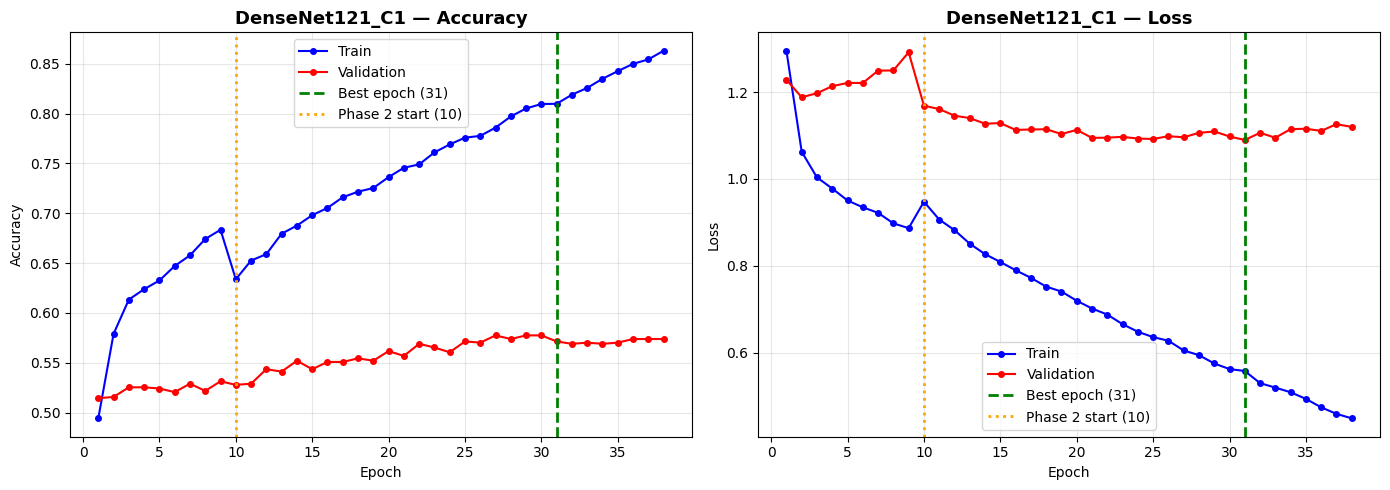

Total epochs: 38 (Phase 1: 9, Phase 2: 29)
Best epoch: 31 (lowest val_loss: 1.0896)
Best val_accuracy: 0.5714
Early stopping at epoch: 38


In [1]:
# ── Training History Visualization — DenseNet-121_C1 ─────────────────────────
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt

output_dir = Path.cwd().resolve()
report_dir = output_dir / 'reports'
MODEL_NAME = "DenseNet121_C1"

# Read phase CSVs with actual epoch numbers
p1 = pd.read_csv(report_dir / 'training_phase1.csv')
p2 = pd.read_csv(report_dir / 'training_phase2.csv')

# Convert to 1-indexed
p1['epoch'] = p1['epoch'] + 1
p2['epoch'] = p2['epoch'] + 1

# Combine
history = pd.concat([p1, p2], ignore_index=True)
epoch_labels = history['epoch'].values

# Best epoch (lowest val_loss)
best_idx = history['val_loss'].idxmin()
best_epoch = int(history.loc[best_idx, 'epoch'])

# Phase 2 start
phase2_start = int(p2['epoch'].iloc[0])

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Accuracy
ax1.plot(epoch_labels, history['accuracy'], 'b-o', markersize=4, label='Train')
ax1.plot(epoch_labels, history['val_accuracy'], 'r-o', markersize=4, label='Validation')
ax1.axvline(x=best_epoch, color='green', linestyle='--', linewidth=2, label=f'Best epoch ({best_epoch})')
ax1.axvline(x=phase2_start, color='orange', linestyle=':', linewidth=2, label=f'Phase 2 start ({phase2_start})')
ax1.set_title(f'{MODEL_NAME} — Accuracy', fontsize=13, fontweight='bold')
ax1.set_ylabel('Accuracy')
ax1.set_xlabel('Epoch')
ax1.legend(fontsize=10)
ax1.grid(alpha=0.3)

# Loss
ax2.plot(epoch_labels, history['loss'], 'b-o', markersize=4, label='Train')
ax2.plot(epoch_labels, history['val_loss'], 'r-o', markersize=4, label='Validation')
ax2.axvline(x=best_epoch, color='green', linestyle='--', linewidth=2, label=f'Best epoch ({best_epoch})')
ax2.axvline(x=phase2_start, color='orange', linestyle=':', linewidth=2, label=f'Phase 2 start ({phase2_start})')
ax2.set_title(f'{MODEL_NAME} — Loss', fontsize=13, fontweight='bold')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Loss')
ax2.legend(fontsize=10)
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()

print(f'Total epochs: {len(history)} (Phase 1: {len(p1)}, Phase 2: {len(p2)})')
print(f'Best epoch: {best_epoch} (lowest val_loss: {history["val_loss"].min():.4f})')
print(f'Best val_accuracy: {history.loc[best_idx, "val_accuracy"]:.4f}')
print(f'Early stopping at epoch: {int(epoch_labels[-1])}')



## 4. Validation and Test Evaluation

The notebook reports the full metrics matrix for both validation and held-out test data. All metrics are computed from the predictions, with argmax labels used for MAE and quadratic weighted kappa.

Loaded best model from: /workspaces/fyp_experiment/Final_year_project/ml_workflow/training/knee_osteoarthritis/DenseNet-121/DenseNet-121_c1(Baseline)/models/best_model.keras
52/52 [==============================] - 7s 113ms/step

  COMPREHENSIVE EVALUATION METRICS MATRIX
  Model : DenseNet121_C1
  Split : Validation
  Metric                                            Value
  ------------------------------------------------------------------------
  Overall Accuracy                                 0.5714
  Balanced Accuracy                                0.5549
  Mean Absolute Error (MAE)                        0.6017
  Macro ROC AUC (ordinal matrix)                   0.8362
  Quadratic Weighted Kappa (QWK)                   0.6670

  PER-CLASS BREAKDOWN
  ------------------------------------------------------------------------
  Class           Precision     Recall         F1    Support
  ------------------------------------------------------------------------
  Healthy            0.60

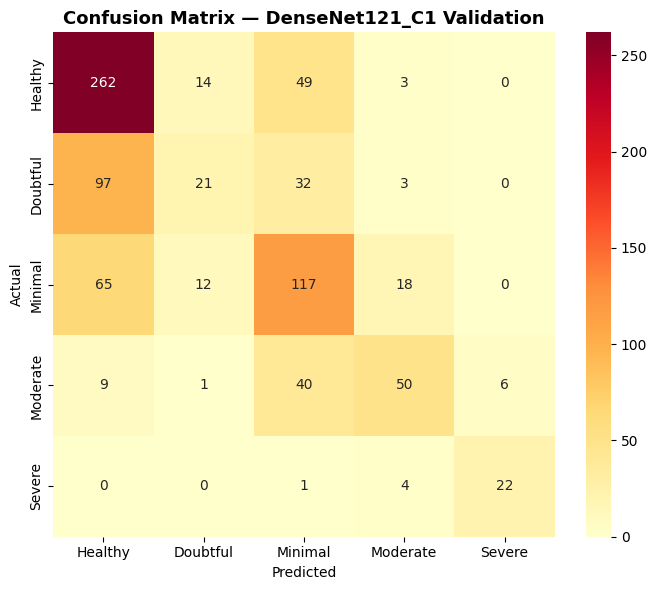

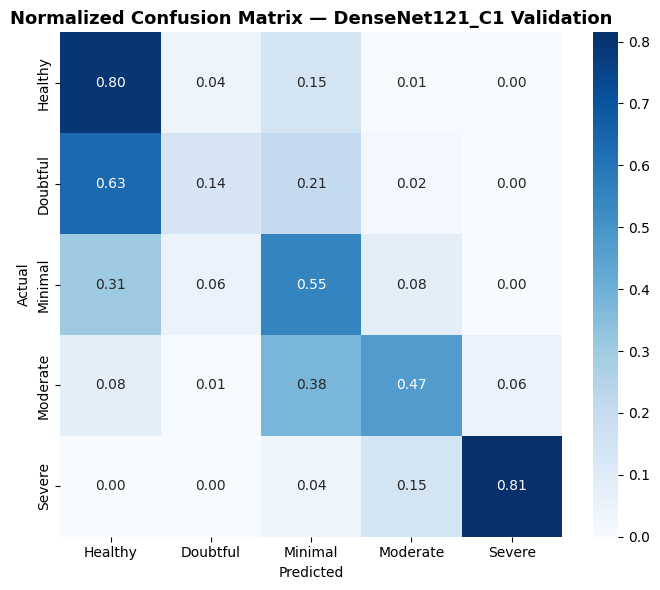

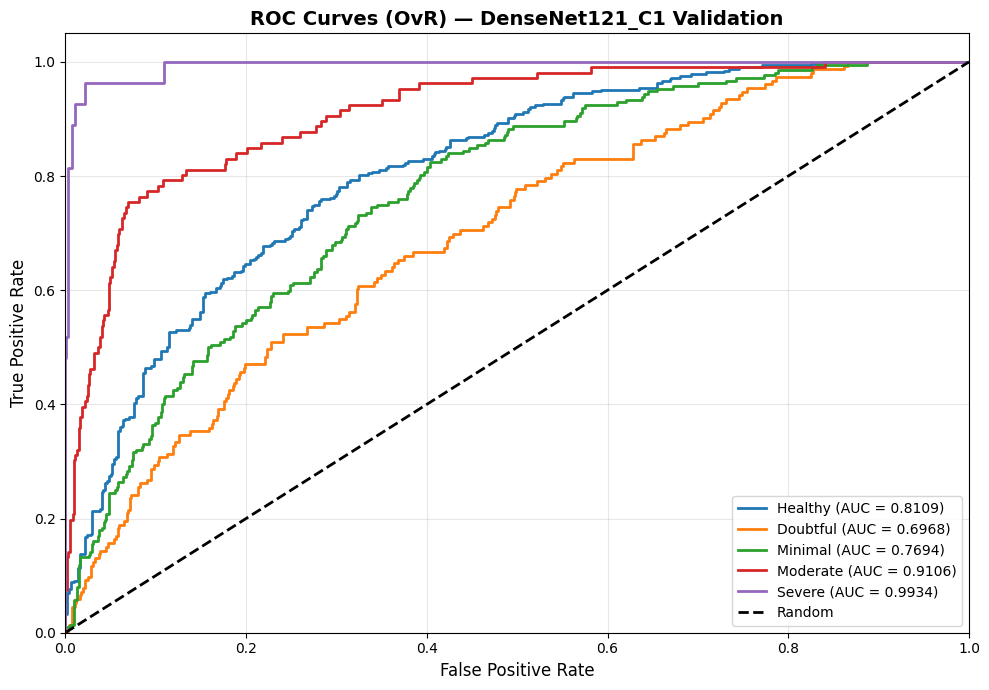

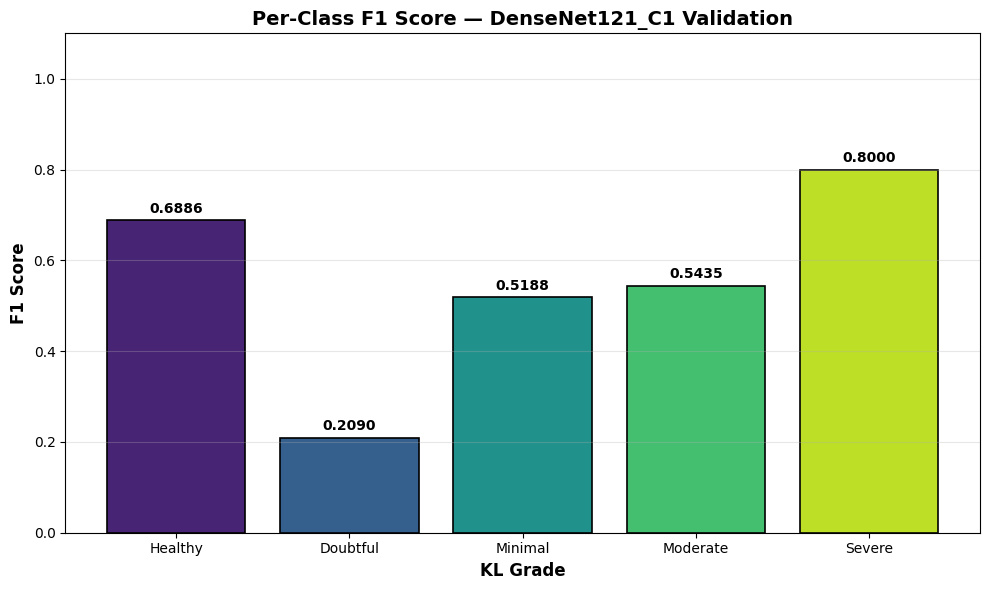

In [ ]:
# ══════════════════════════════════════════════════════════════════════════════
# VALIDATION EVALUATION
# ══════════════════════════════════════════════════════════════════════════════

output_dir = Path.cwd().resolve()
model_dir = output_dir / 'models'
report_dir = output_dir / 'reports'
best_model_path = model_dir / 'best_model.keras'

best_model = tf.keras.models.load_model(str(best_model_path))
print('Loaded best model from:', best_model_path)

# ── Predict on validation set ────────────────────────────────────────────────
valid_generator.reset()
val_probabilities = best_model.predict(valid_generator, verbose=1)
val_true = valid_generator.classes
val_pred_labels = np.argmax(val_probabilities, axis=1)

# ── Comprehensive Metrics Matrix — Validation ────────────────────────────────
val_metrics = comprehensive_evaluation_metrics_matrix(
    y_true       = val_true,
    y_pred_probs = val_probabilities,
    pred_labels  = val_pred_labels,
    split_name   = 'Validation',
    class_names  = CLASS_NAMES,
    model_name   = MODEL_NAME,
    report_dir   = report_dir,
)

# ── Confusion Matrix (raw counts) ────────────────────────────────────────────
plot_confusion_matrix_eval(
    val_true, val_pred_labels, CLASS_NAMES,
    f'Confusion Matrix — {MODEL_NAME} Validation', normalize=False
)

# ── Normalized Confusion Matrix (percentages) ────────────────────────────────
plot_confusion_matrix_eval(
    val_true, val_pred_labels, CLASS_NAMES,
    f'Normalized Confusion Matrix — {MODEL_NAME} Validation', normalize=True
)

# ── ROC Curves ───────────────────────────────────────────────────────────────
plot_roc_curves(val_true, val_probabilities, CLASS_NAMES, f'{MODEL_NAME} Validation')

# ── Per-Class F1 Bar Chart ───────────────────────────────────────────────────
plot_f1_per_class(val_true, val_pred_labels, CLASS_NAMES, f'{MODEL_NAME} Validation')



104/104 [==============================] - 11s 107ms/step

  COMPREHENSIVE EVALUATION METRICS MATRIX
  Model : DenseNet121_C1
  Split : Test
  Metric                                            Value
  ------------------------------------------------------------------------
  Overall Accuracy                                 0.5749
  Balanced Accuracy                                0.5133
  Mean Absolute Error (MAE)                        0.5731
  Macro ROC AUC (ordinal matrix)                   0.8260
  Quadratic Weighted Kappa (QWK)                   0.6935

  PER-CLASS BREAKDOWN
  ------------------------------------------------------------------------
  Class           Precision     Recall         F1    Support
  ------------------------------------------------------------------------
  Healthy            0.6284     0.8232     0.7127        639
  Doubtful           0.2281     0.0878     0.1268        296
  Minimal            0.5263     0.5593     0.5423        447
  Moderate         

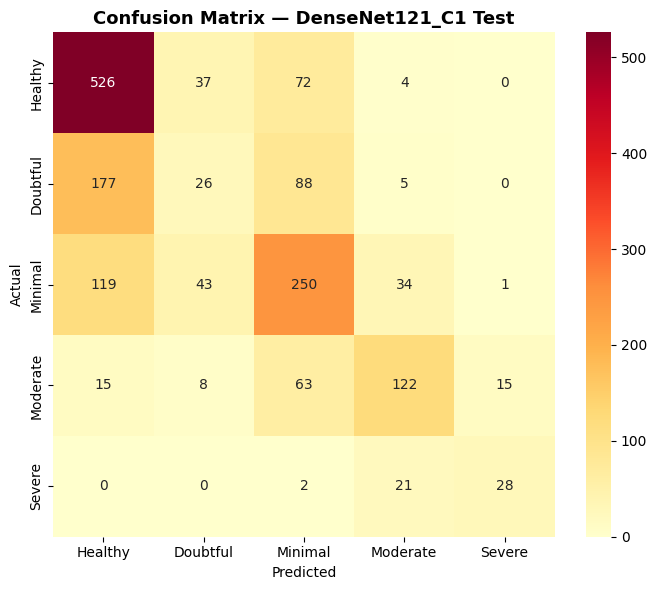

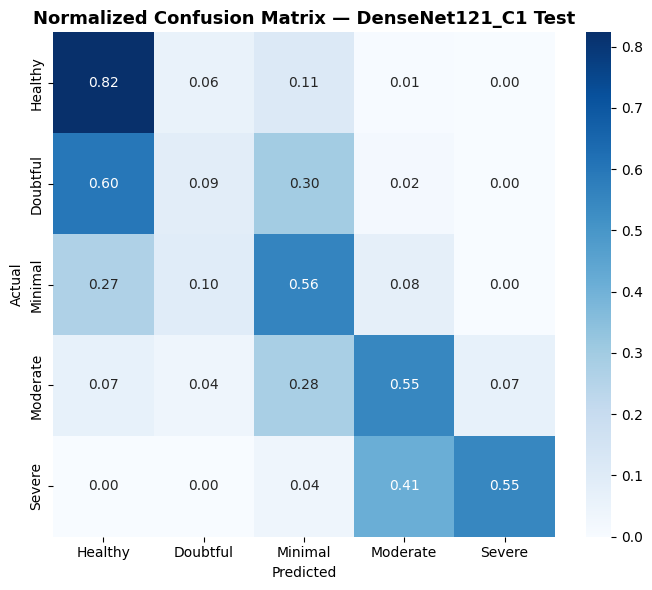

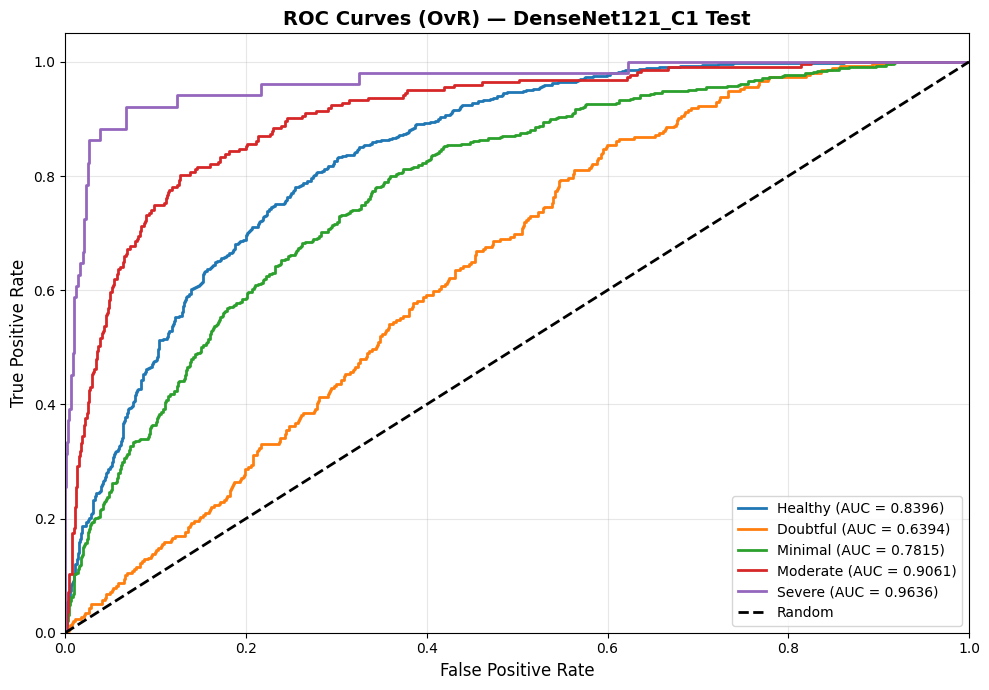

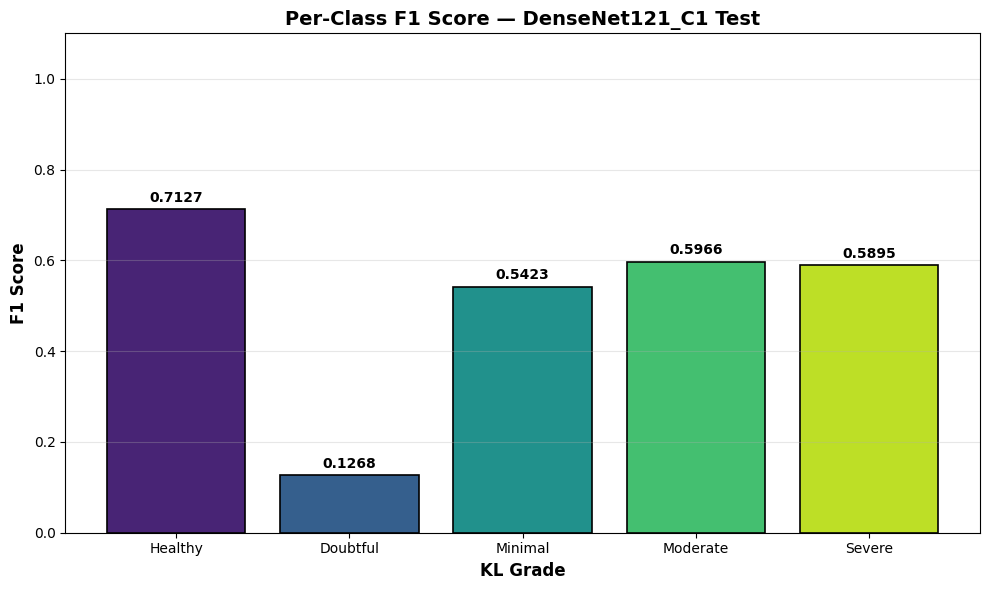

In [29]:
# ══════════════════════════════════════════════════════════════════════════════
# TEST EVALUATION
# ══════════════════════════════════════════════════════════════════════════════

# ── Predict on test set ──────────────────────────────────────────────────────
test_generator.reset()
test_probabilities = best_model.predict(test_generator, verbose=1)
test_true = test_generator.classes
test_pred_labels = np.argmax(test_probabilities, axis=1)

# ── Comprehensive Metrics Matrix — Test ──────────────────────────────────────
test_metrics = comprehensive_evaluation_metrics_matrix(
    y_true       = test_true,
    y_pred_probs = test_probabilities,
    pred_labels  = test_pred_labels,
    split_name   = 'Test',
    class_names  = CLASS_NAMES,
    model_name   = MODEL_NAME,
    report_dir   = report_dir,
)

# ── Confusion Matrix (raw counts) ────────────────────────────────────────────
plot_confusion_matrix_eval(
    test_true, test_pred_labels, CLASS_NAMES,
    f'Confusion Matrix — {MODEL_NAME} Test', normalize=False
)

# ── Normalized Confusion Matrix (percentages) ────────────────────────────────
plot_confusion_matrix_eval(
    test_true, test_pred_labels, CLASS_NAMES,
    f'Normalized Confusion Matrix — {MODEL_NAME} Test', normalize=True
)

# ── ROC Curves ───────────────────────────────────────────────────────────────
plot_roc_curves(test_true, test_probabilities, CLASS_NAMES, f'{MODEL_NAME} Test')

# ── Per-Class F1 Bar Chart ───────────────────────────────────────────────────
plot_f1_per_class(test_true, test_pred_labels, CLASS_NAMES, f'{MODEL_NAME} Test')


## 5. Grad-CAM Interpretation

Grad-CAM is used to verify that the baseline model attends to relevant joint-space and osteophyte regions. The gallery below walks through the test split in class order and saves six random samples per grade.

Grad-CAM target layer: conv5_block16_concat  shape: (None, 7, 7, 1024)
Grad-CAM target layer: conv5_block16_concat
Test data - Healthy


/tmp/ipykernel_2019/2558476749.py:14: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  jet = cm.get_cmap("jet")


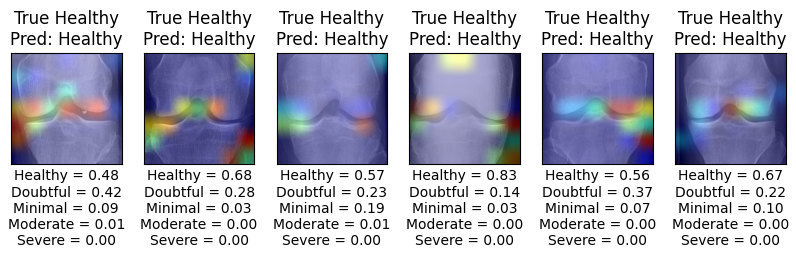

Test data - Doubtful


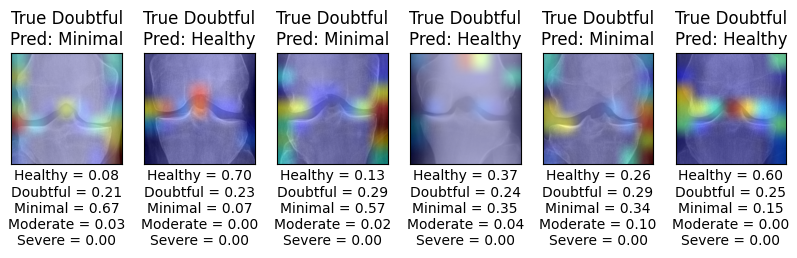

Test data - Minimal


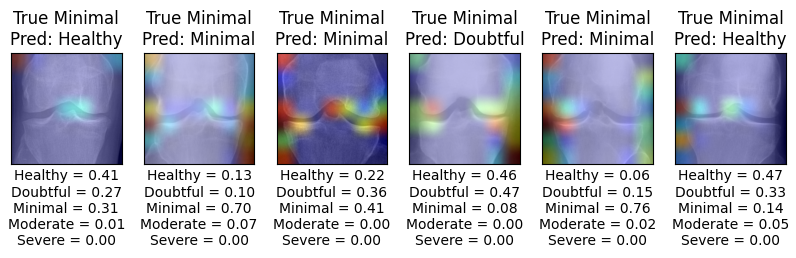

Test data - Moderate


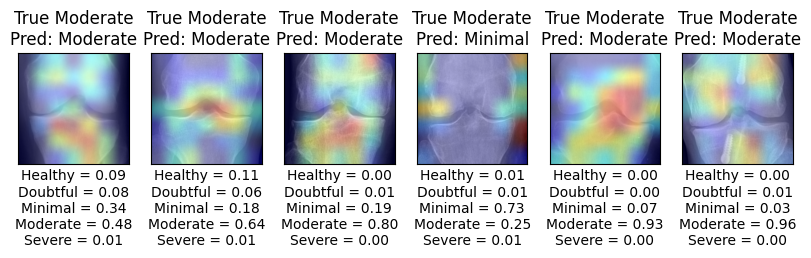

Test data - Severe


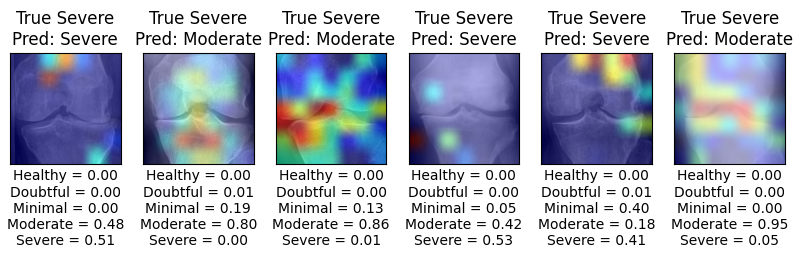

In [10]:
# Build Grad-CAM model (uses the canonical builder implemented above)
try:
    feature_model, head_model, target_layer_name = build_gradcam_model(best_model)
    print('Grad-CAM target layer:', target_layer_name)
except Exception as exc:
    print('Error building Grad-CAM model:', exc)
    raise

import matplotlib.cm as cm

def save_and_display_gradcam(img, heatmap, alpha=0.4):
    heatmap = np.uint8(255 * heatmap)

    jet = cm.get_cmap("jet")

    jet_colors = jet(np.arange(256))[:, :3]
    jet_heatmap = jet_colors[heatmap]

    jet_heatmap = tf.keras.preprocessing.image.array_to_img(jet_heatmap)
    jet_heatmap = jet_heatmap.resize((img.shape[1], img.shape[0]))
    jet_heatmap = tf.keras.preprocessing.image.img_to_array(jet_heatmap)

    superimposed_img = jet_heatmap * alpha + img
    superimposed_img = tf.keras.preprocessing.image.array_to_img(
        superimposed_img
    )

    return superimposed_img

for k, v in test_samples.items():
    print(f"Test data - {CLASS_NAMES[k]}")
    plt.figure(figsize=(10, 28))
    
    class_samples = list(v)
    sample_count = min(6, len(class_samples))
    
    for i in range(sample_count):
        image_name = class_samples[i]
        image_path = Path(image_name)
        if not image_path.is_absolute():
            image_path = TEST_PATH / str(k) / image_name

        if not image_path.exists():
            continue

        raw_image = tf.keras.preprocessing.image.load_img(
            str(image_path), target_size=(IMG_SIZE, IMG_SIZE)
        )
        display_image = tf.keras.preprocessing.image.img_to_array(raw_image).astype(np.uint8)
        img_array = preprocess_for_densenet(display_image)
        img_array = np.expand_dims(img_array, axis=0)

        y_prob = best_model.predict(img_array, verbose=0)[0]
        predicted_label = int(np.argmax(y_prob))

        heatmap = make_gradcam_heatmap(feature_model, head_model, img_array, pred_index=predicted_label)
        image = save_and_display_gradcam(display_image, heatmap)

        plt.subplot(1, 6, 1 + i, xticks=[], yticks=[])
        plt.imshow(image)
        plt.title(
    f"True {CLASS_NAMES[k]}\nPred: {CLASS_NAMES[predicted_label]}"
)
        plt.xlabel(
    "\n".join([f"{c} = {p:.2f}" for c, p in zip(CLASS_NAMES, y_prob)])
)
    plt.show()


## Summary

This notebook is the baseline DenseNet-121 reference for the KOA grading study. It uses direct resizing, standard DenseNet preprocessing, no class balancing, a simple transfer-learning schedule, and full validation/test reporting so later configurations can be compared against a clear starting point.